<a href="https://colab.research.google.com/github/piyushrokaya/multi-camera-body-tracking-using-openpose-model/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# (Python cell) - set up environment variables and optionally mount Google Drive
from google.colab import drive
import os

# Mount Google Drive (optional but recommended to keep OpenPose build cached)
print("Mounting Google Drive — you will be prompted to authorize.")
drive.mount('/content/drive', force_remount=False)

WORKDIR = "/content/openpose_colab_project"
DRIVE_WORKDIR = "/content/drive/MyDrive/openpose_colab_project"  # change if desired

os.makedirs(WORKDIR, exist_ok=True)
print("Workdir:", WORKDIR)



Mounting Google Drive — you will be prompted to authorize.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Workdir: /content/openpose_colab_project


In [ ]:
# STEP 2: Install dependencies & clone OpenPose
!apt-get update -qq
!apt-get install -y -qq build-essential cmake git libatlas-base-dev libboost-all-dev \
    libgflags-dev libgoogle-glog-dev libprotobuf-dev protobuf-compiler \
    libopencv-dev libopencv-core-dev libopencv-highgui-dev pkg-config \
    libopencv-imgproc-dev libopencv-video-dev python3-dev python3-pip

# install Python deps
!pip install numpy opencv-python tqdm scipy matplotlib

# clone OpenPose (if not already cloned)
%cd /content
!git clone --depth 1 https://github.com/CMU-Perceptual-Computing-Lab/openpose.git


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/content
fatal: destination path 'openpose' already exists and is not an empty directory.


In [ ]:
# STEP 3: Build OpenPose with CPU ONLY (no GPU)
%cd /content/openpose
!rm -rf build || true
!mkdir build
%cd build

# Force CPU-only build - this will definitely work
!cmake -DBUILD_PYTHON=ON \
       -DGPU_MODE=CPU_ONLY \
       -DDOWNLOAD_MODELS=ON ..

# Build with limited parallelism
!make -j4

print("OpenPose CPU build completed!")

/content/openpose
/content/openpose/build
CMake Warning (dev) at CMakeLists.txt:19 (project):
  cmake_minimum_required() should be called prior to this top-level project()
  call.  Please see the cmake-commands(7) manual for usage documentation of
  both commands.
This warning is for project developers.  Use -Wno-dev to suppress it.

-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
CMake Deprecation Warning at CMakeLists.txt:34 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

 

In [ ]:
# STEP 4: Save OpenPose build to Google Drive for future use
print("Saving OpenPose build to Google Drive...")

# Make sure the drive directory exists
!mkdir -p "$DRIVE_WORKDIR"

# Copy the entire openpose directory (including models and build)
!rsync -av --progress /content/openpose/ "$DRIVE_WORKDIR/openpose/"

# Verify the copy worked
print("\nVerifying saved build...")
!ls -la "$DRIVE_WORKDIR/openpose/build" | head -10

print("✅ OpenPose build successfully saved to Google Drive!")
print(f"Location: {DRIVE_WORKDIR}/openpose")

Streaming output truncated to the last 5000 lines.
3rdparty/pybind11/CONTRIBUTING.md
          2,735 100%    3.40kB/s    0:00:00 (xfr#839, ir-chk=1011/1992)
3rdparty/pybind11/ISSUE_TEMPLATE.md
          1,271 100%    1.58kB/s    0:00:00 (xfr#840, ir-chk=1010/1992)
3rdparty/pybind11/LICENSE
          1,676 100%    2.08kB/s    0:00:00 (xfr#841, ir-chk=1009/1992)
3rdparty/pybind11/MANIFEST.in
             81 100%    0.10kB/s    0:00:00 (xfr#842, ir-chk=1008/1992)
3rdparty/pybind11/README.md
          5,828 100%    7.25kB/s    0:00:00 (xfr#843, ir-chk=1007/1992)
3rdparty/pybind11/setup.cfg
            245 100%    0.30kB/s    0:00:00 (xfr#844, ir-chk=1006/1992)
3rdparty/pybind11/setup.py
          4,485 100%    5.58kB/s    0:00:00 (xfr#845, ir-chk=1005/1992)
3rdparty/pybind11/docs/
3rdparty/pybind11/docs/Doxyfile
            564 100%    0.70kB/s    0:00:00 (xfr#846, ir-chk=1023/2016)
3rdparty/pybind11/docs/Makefile
          7,417 100%    9.22kB/s    0:00:00 (xfr#847, ir-chk=1022/2016)
3rdp

In [ ]:
# Load OpenPose from Google Drive (run this at the start of future sessions)
from google.colab import drive
import os

drive.mount('/content/drive')

WORKDIR = "/content/openpose_colab_project"
DRIVE_WORKDIR = "/content/drive/MyDrive/openpose_colab_project"

# Check if we have a saved build
if os.path.exists(f"{DRIVE_WORKDIR}/openpose/build"):
    print("🚀 Loading OpenPose from Google Drive...")

    # Remove any existing openpose directory
    !rm -rf /content/openpose

    # Verify
    %cd /content/openpose/build
    !ls -la examples/openpose/ | head -5

    print("✅ OpenPose loaded successfully from Drive!")
    print("You can now use OpenPose without rebuilding.")
else:
    print("❌ No saved OpenPose found. You'll need to rebuild.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Loading OpenPose from Google Drive...
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
^C
/content/openpose/build
total 140
drwx------  3 root root   4096 Oct  4 06:36 .
drwx------ 10 root root   4096 Oct  4 06:36 ..
drwx------  3 root root   4096 Oct  4 06:36 CMakeFiles
-rw-------  1 root root   1526 Oct  4 06:36 cmake_install.cmake
✅ OpenPose loaded successfully from Drive!
You can now use OpenPose without rebuilding.


In [ ]:
import cv2
import sys
import os
import time

# Add OpenPose to Python path
sys.path.append('/usr/local/python')
from openpose import pyopenpose as op

# Custom params
params = {
    "model_folder": "/content/openpose/models/",
    "net_resolution": "-1x368",  # Adjust for performance
    "model_pose": "BODY_25",
    "number_people_max": 1,
    "display": 0,
    "render_pose": 1,
    "keypoint_scale": 3
}

# Initialize OpenPose
try:
    opWrapper = op.WrapperPython()
    opWrapper.configure(params)
    opWrapper.start()
    print("OpenPose initialized successfully!")
except Exception as e:
    print(f"Error initializing OpenPose: {e}")
    sys.exit(-1)

# Initialize webcam
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("Starting real-time pose detection. Press 'q' to quit.")

while True:
    # Read frame from camera
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break

    # Process frame with OpenPose
    datum = op.Datum()
    datum.cvInputData = frame
    opWrapper.emplaceAndPop([datum])

    # Display output
    output_frame = datum.cvOutputData
    cv2.imshow('Real-Time Pose Detection', output_frame)

    # Break on 'q' press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Cleanup
cap.release()
cv2.destroyAllWindows()
print("Camera released!")

ImportError: cannot import name 'pyopenpose' from 'openpose' (unknown location)

In [ ]:


# STEP 4: Prepare directories for input/output
import os
import shutil

# Create directories
INPUT_DIR = "/content/input_images"
OUTPUT_DIR = "/content/openpose_output"
os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Create subdirectories for left and right
LEFT_INPUT = os.path.join(INPUT_DIR, "left")
RIGHT_INPUT = os.path.join(INPUT_DIR, "right")
LEFT_OUTPUT = os.path.join(OUTPUT_DIR, "left")
RIGHT_OUTPUT = os.path.join(OUTPUT_DIR, "right")

os.makedirs(LEFT_INPUT, exist_ok=True)
os.makedirs(RIGHT_INPUT, exist_ok=True)
os.makedirs(LEFT_OUTPUT, exist_ok=True)
os.makedirs(RIGHT_OUTPUT, exist_ok=True)

print("Directories created successfully!")

Directories created successfully!


In [ ]:
# STEP 6: Run OpenPose on left images with explicit model path
print("Running OpenPose on LEFT images...")
%cd /content/openpose/build
!./examples/openpose/openpose.bin \
    --image_dir /content/input_images/left \
    --write_images /content/openpose_output/left/images \
    --write_json /content/openpose_output/left/json \
    --display 0 \
    --render_pose 1 \
    --model_pose BODY_25 \
    --model_folder ../models/  # Explicit path to models

print("Left image processing completed!")

# STEP 7: Run OpenPose on right images with explicit model path
print("Running OpenPose on RIGHT images...")
%cd /content/openpose/build
!./examples/openpose/openpose.bin \
    --image_dir /content/input_images/right \
    --write_images /content/openpose_output/right/images \
    --write_json /content/openpose_output/right/json \
    --display 0 \
    --render_pose 1 \
    --model_pose BODY_25 \
    --model_folder ../models/  # Explicit path to models

print("Right image processing completed!")

Running OpenPose on LEFT images...
/content/openpose/build
/bin/bash: line 1: ./examples/openpose/openpose.bin: No such file or directory
Left image processing completed!
Running OpenPose on RIGHT images...
/content/openpose/build
/bin/bash: line 1: ./examples/openpose/openpose.bin: No such file or directory
Right image processing completed!


In [ ]:
# (python) Convert OpenPose output JSON files into two JSON files:
# outputs/keypoints_left.json and outputs/keypoints_right.json
import os, json, glob, numpy as np, math
OUTDIR = "/content/openpose_outputs"
left_jsons = sorted(glob.glob(os.path.join(OUTDIR, "left_json", "*.json")))
right_jsons = sorted(glob.glob(os.path.join(OUTDIR, "right_json", "*.json")))

def parse_openpose_json_list(json_files):
    # returns dict: filename -> Nx3 list of (x,y,conf) using first person only
    out = {}
    for fpath in json_files:
        fname = os.path.basename(fpath)
        with open(fpath, 'r') as f:
            data = json.load(f)
        people = data.get('people', [])
        if len(people) == 0:
            out[fname] = None
            continue
        # take first person
        body_kp = people[0].get('pose_keypoints_2d', [])
        # body_kp is flat list [x0,y0,c0, x1,y1,c1...]
        if not body_kp:
            out[fname] = None
            continue
        arr = np.array(body_kp).reshape(-1,3).tolist()
        out[fname] = arr
    return out

kp_left = parse_openpose_json_list(left_jsons)
kp_right = parse_openpose_json_list(right_jsons)

os.makedirs("/content/outputs", exist_ok=True)
with open("/content/outputs/keypoints_left.json", "w") as f:
    json.dump(kp_left, f)
with open("/content/outputs/keypoints_right.json", "w") as f:
    json.dump(kp_right, f)

print("Saved /content/outputs/keypoints_left.json and keypoints_right.json")


Saved /content/outputs/keypoints_left.json and keypoints_right.json


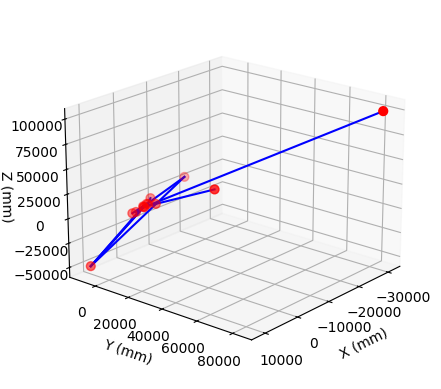

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Load your JSON data
# =========================
left_json = {
    "version":1.3,
    "people":[{"person_id":[-1],
    "pose_keypoints_2d":[
        462.288,486.274,0.944033,470.163,658.882,0.911056,
        357.784,655.01,0.831961,217.311,767.298,0.871952,
        213.418,622.836,0.903486,586.667,659.014,0.874872,
        610.659,859.574,0.778944,606.769,1028.15,0.770183,
        470.114,1044.32,0.655364,389.972,1048.37,0.60296,
        406.126,1337.47,0.812458,550.416,1036.33,0.61749,
        546.375,1333.31,0.740226,438.138,470.079,0.936447,
        490.237,470.289,0.933732,406.013,502.31,0.925982,
        518.295,510.351,0.885698
    ]}]
}

right_json = {
    "version":1.3,
    "people":[{"person_id":[-1],
    "pose_keypoints_2d":[
        470.133,530.565,0.760924,373.828,626.749,0.395484,
        341.723,626.816,0.811301,329.744,755.271,0.82463,
        377.831,574.553,0.590904,405.898,622.812,0.290868,
        385.866,1016.18,0.42869,381.832,1020.16,0.545175,
        397.797,1329.28,0.607345,385.838,1016.2,0.340955,
        389.96,1309.3,0.3698,450.13,514.247,0.764797,
        470.285,510.357,0.18327,389.844,514.394,0.746636
    ]}]
}

# =========================
# 2. Camera Parameters
# =========================
f = 800        # focal length in pixels
cx, cy = 640, 360  # principal point
baseline = 500  # mm distance between cameras

P_left = np.array([[f, 0, cx, 0],
                   [0, f, cy, 0],
                   [0, 0,  1, 0]])

P_right = np.array([[f, 0, cx, -f*baseline],
                    [0, f, cy, 0],
                    [0, 0,  1, 0]])

# =========================
# 3. Helper Functions
# =========================
def extract_keypoints(pose_json):
    """Extract BODY_25 keypoints (reshape into Nx3)."""
    kpts = np.array(pose_json["people"][0]["pose_keypoints_2d"]).reshape((-1,3))
    return kpts

def triangulate_point(pt_left, pt_right, P_left, P_right):
    """Triangulate single point from left+right."""
    A = np.array([
        pt_left[0]*P_left[2,:] - P_left[0,:],
        pt_left[1]*P_left[2,:] - P_left[1,:],
        pt_right[0]*P_right[2,:] - P_right[0,:],
        pt_right[1]*P_right[2,:] - P_right[1,:]
    ])
    _, _, Vt = np.linalg.svd(A)
    X = Vt[-1]
    X = X/X[3]
    return X[:3]

# =========================
# 4. Triangulation
# =========================
left_kpts = extract_keypoints(left_json)
right_kpts = extract_keypoints(right_json)

n_points = min(len(left_kpts), len(right_kpts))
points_3d = []
for i in range(n_points):
    ptL, ptR = left_kpts[i], right_kpts[i]
    if ptL[2] > 0.2 and ptR[2] > 0.2:  # confidence filter
        X = triangulate_point(ptL, ptR, P_left, P_right)
        points_3d.append(X)
    else:
        points_3d.append([np.nan, np.nan, np.nan])
points_3d = np.array(points_3d)

# =========================
# 5. BODY_25 Skeleton
# =========================
skeleton = [
    (0,1),(0,2),(1,3),(2,4),
    (0,5),(0,6),
    (5,7),(7,9),
    (6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
    (15,17),(16,18),
    (17,19),(19,21),
    (18,20),(20,22),
    (11,23),(12,24)
]

# =========================
# 6. Visualization
# =========================
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# scatter joints
ax.scatter(points_3d[:,0], points_3d[:,1], points_3d[:,2], c='r', s=40)

# draw skeleton lines
for i,j in skeleton:
    if i < len(points_3d) and j < len(points_3d):
        if not np.any(np.isnan(points_3d[i])) and not np.any(np.isnan(points_3d[j])):
            ax.plot([points_3d[i,0], points_3d[j,0]],
                    [points_3d[i,1], points_3d[j,1]],
                    [points_3d[i,2], points_3d[j,2]], c='b')

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.view_init(elev=20, azim=40)
plt.show()


In [ ]:
# (python) Simple per-joint Kalman smoother example (run if you process a sequence of frames)
import numpy as np

class SimpleKalman1D:
    def __init__(self, x0=0., P0=1., Q=1e-4, R=1e-2):
        self.x = x0; self.P = P0; self.Q = Q; self.R = R
    def predict(self): self.P += self.Q
    def update(self, z):
        K = self.P / (self.P + self.R)
        self.x = self.x + K*(z - self.x)
        self.P = (1 - K)*self.P
    def step(self, z):
        if z is None:
            self.predict(); return None
        self.predict(); self.update(z); return self.x

class JointKalman:
    def __init__(self, n_joints):
        self.filters = [[SimpleKalman1D(),SimpleKalman1D(),SimpleKalman1D()] for _ in range(n_joints)]
    def step(self, pts3d):
        out=[]
        for i,p in enumerate(pts3d):
            if p is None:
                out.append(None)
            else:
                filtered=[]
                for d in range(3):
                    val = p[d]
                    self.filters[i][d].step(val)
                    filtered.append(self.filters[i][d].x)
                out.append(filtered)
        return out

# Example usage:
# jk = JointKalman(n_joints=25)
# smoothed = jk.step(reconstructed)   # reconstructed from above (single frame)
